2026-05-18 00:27:33,657 - INFO -  Data loaded successfully from ..\data\raw\processed\tickets_dataset.csv
2026-05-18 00:27:34,273 - INFO -  Data cleaned successfully
2026-05-18 00:27:38,392 - INFO - Splitting data into train and test sets with test size 0.2 and random state 42...
2026-05-18 00:27:38,397 - INFO - Data splitting completed.
2026-05-18 00:27:38,597 - INFO - Loading training data...
2026-05-18 00:27:38,719 - INFO - Initializing the model pipeline with TF-IDF and Logistic Regression...
2026-05-18 00:27:38,721 - INFO - Training the model on 3200 rows...


Train and test datasets saved. Train: 3200 rows, Test: 800 rows.
 --- Starting model training --- 


2026-05-18 00:27:39,902 - INFO - Model training completed.
2026-05-18 00:27:39,904 - INFO - Saving the trained model to c:\Projects\ai-ml-engineering-portfolio\01-nlp-baseline-ticket-classifier\models\baseline_pipeline.joblib...
2026-05-18 00:27:39,957 - INFO - Model saved successfully.
2026-05-18 00:27:39,961 - INFO - Loading the test data...
2026-05-18 00:27:39,995 - INFO - Loading the trained model from c:\Projects\ai-ml-engineering-portfolio\01-nlp-baseline-ticket-classifier\models\baseline_pipeline.joblib...
2026-05-18 00:27:40,016 - INFO - Model loaded successfully. Making predictions on the test set...


 --- Starting model evaluation --- 
 --- Evaluating on test set --- 


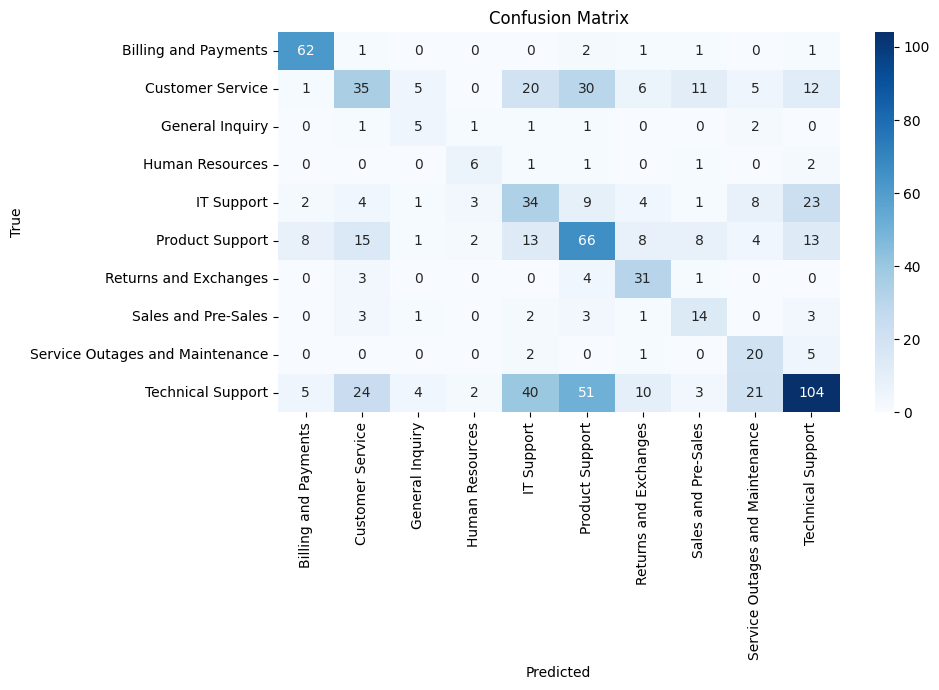

({'Accuracy': 0.47125,
  'Macro F1': 0.47610687551349873,
  'Weighted F1': 0.4683339463682452},
 array([[ 62,   1,   0,   0,   0,   2,   1,   1,   0,   1],
        [  1,  35,   5,   0,  20,  30,   6,  11,   5,  12],
        [  0,   1,   5,   1,   1,   1,   0,   0,   2,   0],
        [  0,   0,   0,   6,   1,   1,   0,   1,   0,   2],
        [  2,   4,   1,   3,  34,   9,   4,   1,   8,  23],
        [  8,  15,   1,   2,  13,  66,   8,   8,   4,  13],
        [  0,   3,   0,   0,   0,   4,  31,   1,   0,   0],
        [  0,   3,   1,   0,   2,   3,   1,  14,   0,   3],
        [  0,   0,   0,   0,   2,   0,   1,   0,  20,   5],
        [  5,  24,   4,   2,  40,  51,  10,   3,  21, 104]]))

In [1]:
import sys
import os
sys.path.append(os.path.abspath('../'))
from src.data_loader import DataLoader
from src.preprocessing import clean_text, stem_text, split_data
from src.train import train_model
from src.evaluate import test_model
import matplotlib.pyplot as plt
from nltk.stem.snowball import SnowballStemmer

loader = DataLoader('..\\data\\raw\\processed\\tickets_dataset.csv')
df = loader.get_clean_ticket_dataset()

LANGUAGES = {
    'en': 'english',
    'de': 'german',
    'es': 'spanish',
    'fr': 'french',
    'pt': 'portuguese'
}

df['cleaned_context'] = df['context_problem'].apply(clean_text)

df['stemmed_context'] = df['cleaned_context']
for lang_code, lang_name in LANGUAGES.items():
    stemmer = SnowballStemmer(lang_name)
    df.loc[df['language'] == lang_code, 'stemmed_context'] = df.loc[df['language'] == lang_code, 'cleaned_context'].apply(lambda x: stem_text(x, stemmer))

TRAINING_COL = 'stemmed_context'
TARGET_COL = 'queue'

train_df, test_df = split_data(df=df, target_column=TARGET_COL)

train_df.to_csv('..\\data\\raw\\processed\\train.csv', index=False)
test_df.to_csv('..\\data\\raw\\processed\\test.csv', index=False)

print(f"Train and test datasets saved. Train: {train_df.shape[0]} rows, Test: {test_df.shape[0]} rows.")

print(" --- Starting model training --- ")

train_model(training_col=TRAINING_COL, target_col=TARGET_COL)

print(" --- Starting model evaluation --- ")
print(" --- Evaluating on test set --- ")

test_model(training_col=TRAINING_COL, target_col=TARGET_COL)